# Модель аналитики каналов по русскоязычному сегменту телеграмм категории в "Лингвистика"

- Данные были собраны с TGStat

## 0. Импорты

In [78]:
import urllib.request, os, warnings
import pandas as pd
import numpy as np
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

try:
    import lightgbm as lgb
    print(f'LightGBM {lgb.__version__}')
except ImportError:
    raise ImportError('pip install lightgbm')

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    print(f'Optuna {optuna.__version__}')
except ImportError:
    raise ImportError('pip install optuna')

RANDOM_STATE = 42

LightGBM 4.6.0
Optuna 4.8.0


## 1. Загрузка данных

In [79]:
# Загрузка данных
CSV_PATH = 'language_channels.csv'
if not os.path.exists(CSV_PATH):
    print('Датасет не найден')
    exit(-1)

df = pd.read_csv(CSV_PATH, low_memory=False)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns[:15])}...')

# Предобработка и очистка данных
REACH_COLS = ['avg_ad_reach_12h', 'avg_ad_reach_24h', 'avg_ad_reach_48h']
for col in REACH_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['avg_reach'] = df[REACH_COLS].mean(axis=1) # усреднение по разным временным окнам для более стабильной оценки охвата

# Вычисление возраста канала в днях
if 'channel_created_date' in df.columns:
    df['channel_age_days'] = (
        pd.to_datetime('today', utc=True) -
        pd.to_datetime(df['channel_created_date'], errors='coerce', utc=True)
    ).dt.days.fillna(0).clip(lower=0)
else:
    df['channel_age_days'] = 0

# Очистка данных по avg_reach: удаляем строки с нулевым или отрицательным охватом, а также выбросы выше 99.5 перцентиля
df_clean = df[df['avg_reach'] > 0].dropna(subset=['avg_reach']).copy()
p995 = df_clean['avg_reach'].quantile(0.995)
df_clean = df_clean[df_clean['avg_reach'] <= p995].reset_index(drop=True)
print(f'Строк после очистки: {len(df_clean)}')
print(f'avg_reach: min={df_clean["avg_reach"].min():.0f}, max={df_clean["avg_reach"].max():,.0f}, median={df_clean["avg_reach"].median():.0f}')

Shape: (4246, 42)
Columns: ['source_page', 'source_page_type', 'channel_url', 'username', 'title', 'description', 'subscribers', 'country', 'category', 'rank_subscribers', 'title_length', 'description_length', 'word_count', 'has_contact', 'language_hint']...
Строк после очистки: 3276
avg_reach: min=1, max=5,900, median=106


## 2. Feature Engineering

In [80]:
# Категориальные признаки
CAT_CANDIDATES = ['country', 'category', 'language', 'language_hint', 'channel_type']
CAT_COLS = [c for c in CAT_CANDIDATES if c in df_clean.columns]
print(f'Категориальные: {CAT_COLS}')
for col in CAT_COLS:
    n_unique = df_clean[col].nunique()
    print(f'  {col}: {n_unique} уникальных')
    df_clean[col] = df_clean[col].fillna('__missing__').astype('category')

# Числовые признаки
NUM_COLS_BASE = [
    'subscribers', 'rank_subscribers',
    'title_length', 'description_length', 'word_count', 'has_contact',
    'channel_age_days',
    'subscriptions_24h', 'unsubscriptions_24h', 'net_subscriptions_24h',
    'stories_boosts', 'stories_reactions', 'stories_forwards',
    'stories_reach_12h', 'stories_reach_24h', 'stories_reach_48h',
    'posts_total', 'posts_yesterday', 'posts_week', 'posts_month',
    'readers_percent', 'readers_24h_percent', 'male_percent', 'female_percent',
    'posts_per_week_estimated', 'ad_reach_to_subscribers_ratio',
    'stories_reach_to_subscribers_ratio',
]
NUM_COLS_BASE = [c for c in NUM_COLS_BASE if c in df_clean.columns]

for col in NUM_COLS_BASE:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0)

# Создание новых признаков
df_clean['log_subs_x_readers']        = np.log1p(df_clean['subscribers'].clip(0)) * df_clean['readers_percent'].clip(0,100)/100.0
df_clean['age_x_posts_week']          = np.log1p(df_clean['channel_age_days'].clip(0)) * np.log1p(df_clean['posts_per_week_estimated'].clip(0))
df_clean['subs_growth_rate']          = df_clean['net_subscriptions_24h'] / df_clean['subscribers'].clip(1)
df_clean['readers_24h_pct_sq']        = (df_clean['readers_24h_percent'].clip(0,100)/100.0)**2
df_clean['abs_readers_24h_clean']     = df_clean['readers_24h_percent'].clip(0,100)/100.0 * df_clean['subscribers'].clip(0)
df_clean['log_abs_readers_24h_clean'] = np.log1p(df_clean['abs_readers_24h_clean'].clip(0))
df_clean['sub_per_age']               = df_clean['subscribers'].clip(0) / df_clean['channel_age_days'].clip(1)
df_clean['log_sub_per_age']           = np.log1p(df_clean['sub_per_age'].clip(0))
df_clean['posts_consistency']         = df_clean['posts_month'].clip(0) / (df_clean['posts_per_week_estimated'].clip(0)*4.33+1)
df_clean['readers_x_posts']           = df_clean['readers_24h_percent'].clip(0,100)/100.0 * np.log1p(df_clean['posts_week'].clip(0))
df_clean['male_female_ratio']         = (df_clean['male_percent'].clip(0,100) - df_clean['female_percent'].clip(0,100)) / 100.0

if 'rank_subscribers' in df_clean.columns:
    df_clean['log_rank']        = np.log1p(df_clean['rank_subscribers'].clip(0))
    df_clean['subs_rank_ratio'] = np.log1p(df_clean['subscribers'].clip(0)) / (np.log1p(df_clean['rank_subscribers'].clip(0)) + 1)
else:
    df_clean['log_rank'] = df_clean['subs_rank_ratio'] = 0.0

df_clean['subs_quantile_bin'] = pd.qcut(
    df_clean['subscribers'].clip(0), q=10, labels=False, duplicates='drop'
).fillna(0).astype(float)

if 'stories_avg_reach' in df_clean.columns:
    df_clean['stories_to_ad_ratio'] = np.log1p(df_clean['stories_avg_reach'].clip(0)) / (np.log1p(df_clean['avg_ad_reach_1_post'].clip(0)) + 1e-6)
else:
    df_clean['stories_to_ad_ratio'] = 0.0

# Новые признаки
df_clean['log_subs_sq']    = np.log1p(df_clean['subscribers'].clip(0)) ** 2 # квадрат логарифма может помочь модели уловить нелинейные эффекты роста аудитории
df_clean['reach_velocity'] = df_clean['avg_reach'] / df_clean['channel_age_days'].clip(1) # скорость роста охвата может быть важным признаком для предсказания будущего охвата
df_clean['log_reach_vel']  = np.log1p(df_clean['reach_velocity'].clip(0)) # логарифм скорости роста охвата может помочь модели уловить экспоненциальные эффекты роста

# Итоговый список признаков
INTERACTION_COLS = [
    'log_subs_x_readers', 'age_x_posts_week', 'subs_growth_rate',
    'readers_24h_pct_sq', 'abs_readers_24h_clean', 'log_abs_readers_24h_clean',
    'sub_per_age', 'log_sub_per_age', 'posts_consistency', 'readers_x_posts',
    'male_female_ratio', 'log_rank', 'subs_rank_ratio', 'subs_quantile_bin',
    'stories_to_ad_ratio', 'log_subs_sq', 'log_reach_vel',
]

NUM_COLS = NUM_COLS_BASE + INTERACTION_COLS
ALL_COLS = NUM_COLS + CAT_COLS
print(f'Числовых: {len(NUM_COLS)}, категориальных: {len(CAT_COLS)}, всего: {len(ALL_COLS)}')

Категориальные: ['country', 'category', 'language_hint']
  country: 1 уникальных
  category: 1 уникальных
  language_hint: 14 уникальных
Числовых: 44, категориальных: 3, всего: 47


## 2.2 TF-IDF features

In [81]:
# TF-IDF признаки для текстовых полей с SVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import pandas as pd
import numpy as np

TEXT_COLS = ['title', 'description', 'text_description']
TEXT_COLS = [c for c in TEXT_COLS if c in df_clean.columns]

def fill_text(df, col):
    return df[col].fillna('').astype(str).str.lower().str.strip()

SVD_COMPONENTS = 50

tfidf_features = []
tfidf_models = {}
tfidf_cols_all = []

for col in TEXT_COLS:
    corpus = fill_text(df_clean, col)

    # Пропускаем совсем пустые колонки
    if corpus.str.len().sum() == 0:
        print(f'{col}: пропущен (пустой текст)')
        continue

    tfidf = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=3,
        sublinear_tf=True,
        strip_accents='unicode',
    )

    X_tfidf = tfidf.fit_transform(corpus)

    # Если признаков слишком мало — SVD не применяем
    max_possible_components = min(X_tfidf.shape[0] - 1, X_tfidf.shape[1] - 1)
    n_comp = min(SVD_COMPONENTS, max_possible_components)

    if n_comp < 2:
        print(f'{col}: пропущен (слишком мало TF-IDF признаков для SVD, shape={X_tfidf.shape})')
        continue

    svd = TruncatedSVD(n_components=n_comp, random_state=RANDOM_STATE)
    X_svd = svd.fit_transform(X_tfidf)

    tfidf_models[col] = (tfidf, svd)

    cols = [f'svd_{col}_{i}' for i in range(n_comp)]
    tfidf_cols_all.extend(cols)

    tfidf_features.append(
        pd.DataFrame(X_svd, columns=cols, index=df_clean.index)
    )

    print(f'{col}: TF-IDF {X_tfidf.shape} -> SVD {n_comp}d, '
          f'explained={svd.explained_variance_ratio_.sum():.3f}')

# Объединение TF-IDF признаков
if tfidf_features:
    df_tfidf = pd.concat(tfidf_features, axis=1)
else:
    df_tfidf = pd.DataFrame(index=df_clean.index)

print(f'TF-IDF признаков: {df_tfidf.shape[1]}')

# Добавляем в df_clean только новые колонки
if not df_tfidf.empty:
    df_clean = pd.concat(
        [df_clean.reset_index(drop=True), df_tfidf.reset_index(drop=True)],
        axis=1
    )

# Обновляем NUM_COLS без дублей
NUM_COLS = list(dict.fromkeys(NUM_COLS + list(df_tfidf.columns)))

print(f'Итого признаков: {len(NUM_COLS) + len(CAT_COLS)}')

title: TF-IDF (3276, 811) -> SVD 50d, explained=0.393
description: TF-IDF (3276, 986) -> SVD 50d, explained=0.421
text_description: TF-IDF (3276, 1306) -> SVD 50d, explained=0.424
TF-IDF признаков: 150
Итого признаков: 197


## 3. Сборка DataFrame

In [82]:
# Логарифмическое преобразование для числовых признаков с большим разбросом
LOG_TRANSFORM = [c for c in ['subscribers', 'rank_subscribers', 'posts_total', 'stories_avg_reach'] if c in NUM_COLS]

# Функция для подготовки финального датафрейма с нужными признаками и преобразованиями
def make_df(df_src):
    out = {}
    for col in NUM_COLS:
        vals = pd.to_numeric(df_src[col], errors='coerce').values.astype(float)
        if col in LOG_TRANSFORM:
            vals = np.log1p(np.clip(vals, 0, None))
        out[col] = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
    for col in CAT_COLS:
        out[col] = df_src[col]
    return pd.DataFrame(out, index=df_src.index)

# Подготовка данных для модели
y_all  = np.log1p(df_clean['avg_reach'].values)
subs   = df_clean['subscribers'].values.astype(float)
df_X   = make_df(df_clean)

# Разбиение на train/test
idx = np.arange(len(df_clean))
idx_tr, idx_te = train_test_split(idx, test_size=0.25, random_state=RANDOM_STATE)

# Финальные train/test наборы
X_tr, X_te = df_X.iloc[idx_tr], df_X.iloc[idx_te]
y_tr, y_te = y_all[idx_tr], y_all[idx_te]
subs_te = subs[idx_te]

print(f'Train: {len(idx_tr)} | Test: {len(idx_te)}')
print(f'X shape: {X_tr.shape}')
print(f'Cat колонки: {[c for c in X_tr.columns if X_tr[c].dtype.name == "category"]}')

Train: 2457 | Test: 819
X shape: (2457, 197)
Cat колонки: ['country', 'category', 'language_hint']


## 4. HGBR с базовыми параметрами

In [58]:
# Бейзлайн модель: HistGradientBoostingRegressor с базовыми параметрами и ранней остановкой
hgbr_baseline = HistGradientBoostingRegressor(
    loss='absolute_error', max_iter=500, learning_rate=0.025,
    max_depth=5, min_samples_leaf=15, l2_regularization=0.3,
    random_state=RANDOM_STATE, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=30,
)
hgbr_baseline.fit(X_tr, y_tr)
p_hgbr = hgbr_baseline.predict(X_te)

r2_hgbr = r2_score(y_te, p_hgbr)
rmse_hgbr = np.sqrt(mean_squared_error(y_te, p_hgbr))
print(f'HGBR: R²={r2_hgbr:.4f}  RMSE={np.sqrt(mean_squared_error(y_te, p_hgbr)):.4f}')

HGBR: R²=0.9531  RMSE=0.2646


## 4.1 HGBR с optuna

In [59]:
N_TRIALS = 60
N_FOLDS  = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def objective_hgbr(trial):
    params = {
        'loss': 'absolute_error',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_iter': trial.suggest_int('max_iter', 200, 2000),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 255),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 100),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-6, 10.0, log=True),
        'max_bins': trial.suggest_int('max_bins', 64, 255),
        'early_stopping': True,
        'validation_fraction': 0.1,
        'n_iter_no_change': 30,
        'tol': trial.suggest_float('tol', 1e-8, 1e-4, log=True),
        'random_state': RANDOM_STATE,
    }

    oof_preds = np.zeros(len(X_tr))

    for fold_idx, (tr_i, val_i) in enumerate(kf.split(X_tr)):
        model = HistGradientBoostingRegressor(**params)
        model.fit(X_tr.iloc[tr_i], y_tr[tr_i])
        oof_preds[val_i] = model.predict(X_tr.iloc[val_i])

    rmse = np.sqrt(mean_squared_error(y_tr, oof_preds))
    return rmse

print(f'Optuna HGBR: {N_TRIALS} trials x {N_FOLDS}-fold CV...')
study_hgbr = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_hgbr.optimize(objective_hgbr, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nЛучший trial HGBR: RMSE(OOF)={study_hgbr.best_value:.4f}')
print('Лучшие параметры HGBR:')
for k, v in study_hgbr.best_params.items():
    print(f'  {k}: {v}')

Optuna HGBR: 60 trials x 5-fold CV...


Best trial: 41. Best value: 0.208729: 100%|██████████| 60/60 [08:07<00:00,  8.13s/it]


Лучший trial HGBR: RMSE(OOF)=0.2087
Лучшие параметры HGBR:
  learning_rate: 0.06665458335789567
  max_iter: 936
  max_leaf_nodes: 102
  max_depth: 5
  min_samples_leaf: 11
  l2_regularization: 0.5120801335146327
  max_bins: 89
  tol: 1.4092691838715148e-05


## 4.2 HGBR финальная модель и метрики

In [60]:
# Финальная модель с лучшими параметрами на полном тренировочном наборе и оценка на тесте
best_params_hgbr = study_hgbr.best_params.copy()
best_params_hgbr.update({
    'loss': 'absolute_error',
    'early_stopping': True,
    'validation_fraction': 0.1,
    'n_iter_no_change': 30,
    'random_state': RANDOM_STATE,
})

# Небольшой буст числа итераций
best_params_hgbr['max_iter'] = int(best_params_hgbr.get('max_iter', 500) * 1.2)

# Обучение финальной модели и оценка на тесте
hgbr_final = HistGradientBoostingRegressor(**best_params_hgbr)
hgbr_final.fit(X_tr, y_tr)

p_hgbr_final = hgbr_final.predict(X_te)
r2_hgbr_final = r2_score(y_te, p_hgbr_final)
rmse_hgbr_final = np.sqrt(mean_squared_error(y_te, p_hgbr_final))

def metrics_full(y_true, y_pred, label, subs_arr):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = np.mean(np.abs(y_true - y_pred))
    r2   = r2_score(y_true, y_pred)
    ro   = np.sqrt(mean_squared_error(
        np.expm1(y_true),
        np.expm1(np.clip(y_pred, 0, np.log1p(1e8)))
    ))
    print(f'--- {label} ---')
    print(f'  R²={r2:.4f}  RMSE(log)={rmse:.4f}  MAE(log)={mae:.4f}  RMSE(просм)={ro:,.0f}')
    for name, lo, hi in [('Малые   ', 0, 1000), ('Средние ', 1000, 5000),
                         ('Крупные ', 5000, 15000), ('Мега    ', 15000, 1e9)]:
        m = (subs_arr > lo) & (subs_arr <= hi)
        if m.sum() < 5:
            continue
        print(f'    {name} n={m.sum():4d}: R²={r2_score(y_true[m], y_pred[m]):.3f}, '
              f'RMSE={np.sqrt(mean_squared_error(y_true[m], y_pred[m])):.3f}')
    return r2

print('=' * 65)
print('МЕТРИКИ')
print('=' * 65)
metrics_full(y_te, p_hgbr_final, 'HistGradientBoostingRegressor (Optuna)', subs_te)

МЕТРИКИ
--- HistGradientBoostingRegressor (Optuna) ---
  R²=0.9522  RMSE(log)=0.2672  MAE(log)=0.0907  RMSE(просм)=301
    Малые    n= 293: R²=0.935, RMSE=0.175
    Средние  n= 330: R²=0.986, RMSE=0.087
    Крупные  n= 136: R²=0.937, RMSE=0.284
    Мега     n=  58: R²=0.962, RMSE=0.239


0.9522473579837016

## 5. LightGBM с базовыми параметрами

In [61]:
# LightGBM с базовыми параметрами и ранней остановкой
lgb_params_default = {
    'objective': 'regression_l1',
    'metric': 'rmse',
    'n_estimators': 1000,
    'learning_rate': 0.02,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'subsample_freq': 1,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': RANDOM_STATE,
    'verbose': -1,
    'n_jobs': -1,
}
lgb_default = lgb.LGBMRegressor(**lgb_params_default)
lgb_default.fit(
    X_tr, y_tr,
    eval_set=[(X_te, y_te)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)
p_lgb_default = lgb_default.predict(X_te)
r2_lgb_default = r2_score(y_te, p_lgb_default)
print(f'LightGBM: R²={r2_lgb_default:.4f}  RMSE={np.sqrt(mean_squared_error(y_te, p_lgb_default)):.4f}')
print(f'  iters={lgb_default.best_iteration_}')

LightGBM: R²=0.9440  RMSE=0.2893
  iters=1000


## 5.1 LGBM с optuna

In [62]:
# Оптимизация гиперпараметров LightGBM с помощью Optuna и K-Fold CV
N_TRIALS = 60
N_FOLDS  = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Функция для оптимизации, которая обучает модель на каждом фолде и возвращает RMSE по OOF предсказаниям
def objective(trial):
    params = {
        'objective': 'regression_l1',
        'metric': 'rmse',
        'verbose': -1,
        'n_jobs': -1,
        'random_state': RANDOM_STATE,
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 60),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'subsample_freq': 1,
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 0.5),
    }

    # OOF предсказания для оценки RMSE на тренировочных данных
    oof_preds = np.zeros(len(idx_tr))
    for fold_idx, (tr_i, val_i) in enumerate(kf.split(X_tr)):
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr.iloc[tr_i], y_tr[tr_i],
            eval_set=[(X_tr.iloc[val_i], y_tr[val_i])],
            callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(-1)],
        )
        oof_preds[val_i] = model.predict(X_tr.iloc[val_i])
    return np.sqrt(mean_squared_error(y_tr, oof_preds))

# Запуск оптимизации
print(f'Optuna: {N_TRIALS} trials x {N_FOLDS}-fold CV...')
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

# Вывод лучших параметров и RMSE на OOF предсказаниях
print(f'\nЛучший trial: RMSE(OOF)={study.best_value:.4f}')
print('Лучшие параметры:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Optuna: 60 trials x 5-fold CV...


Best trial: 37. Best value: 0.192143: 100%|██████████| 60/60 [12:32<00:00, 12.55s/it]


Лучший trial: RMSE(OOF)=0.1921
Лучшие параметры:
  n_estimators: 1819
  learning_rate: 0.017895326889816664
  num_leaves: 71
  max_depth: 6
  min_child_samples: 10
  subsample: 0.7111485732157405
  colsample_bytree: 0.5831548413769337
  reg_alpha: 0.09119433132929687
  reg_lambda: 0.21026523426747298
  min_split_gain: 0.07187277258460233


## 5.2 LGBM финальная модель и метрики

In [63]:
# Финальная модель с лучшими параметрами на полном тренировочном наборе и оценка на тесте
best_params = study.best_params.copy()
best_params.update({
    'objective': 'regression_l1', 'metric': 'rmse',
    'verbose': -1, 'n_jobs': -1, 'random_state': RANDOM_STATE, 'subsample_freq': 1,
})
best_params['n_estimators'] = int(best_params.get('n_estimators', 500) * 1.2)

# Обучение финальной модели и оценка на тесте
lgb_final = lgb.LGBMRegressor(**best_params)
lgb_final.fit(X_tr, y_tr, callbacks=[lgb.log_evaluation(-1)])
p_lgb_final = lgb_final.predict(X_te)
r2_final    = r2_score(y_te, p_lgb_final)
rmse_final  = np.sqrt(mean_squared_error(y_te, p_lgb_final))

# Функция для вывода метрик и сравнения по сегментам
def metrics_full(y_true, y_pred, label, subs_arr):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = np.mean(np.abs(y_true - y_pred))
    r2   = r2_score(y_true, y_pred)
    ro   = np.sqrt(mean_squared_error(np.expm1(y_true), np.expm1(np.clip(y_pred, 0, np.log1p(1e8)))))
    print(f'--- {label} ---')
    print(f'  R²={r2:.4f}  RMSE(log)={rmse:.4f}  MAE(log)={mae:.4f}  RMSE(просм)={ro:,.0f}')
    for name, lo, hi in [('Малые   ', 0, 1000), ('Средние ', 1000, 5000),
                          ('Крупные ', 5000, 15000), ('Мега    ', 15000, 1e9)]:
        m = (subs_arr > lo) & (subs_arr <= hi)
        if m.sum() < 5: continue
        print(f'    {name} n={m.sum():4d}: R²={r2_score(y_true[m], y_pred[m]):.3f}, RMSE={np.sqrt(mean_squared_error(y_true[m], y_pred[m])):.3f}')
    return r2

print('=' * 65)
print('МЕТРИКИ')
print('=' * 65)
metrics_full(y_te, p_lgb_final, 'LightGBM GBDT (Optuna)', subs_te)

МЕТРИКИ
--- LightGBM GBDT (Optuna) ---
  R²=0.9487  RMSE(log)=0.2768  MAE(log)=0.0841  RMSE(просм)=309
    Малые    n= 293: R²=0.950, RMSE=0.153
    Средние  n= 330: R²=0.991, RMSE=0.071
    Крупные  n= 136: R²=0.960, RMSE=0.227
    Мега     n=  58: R²=0.960, RMSE=0.244


0.9487272491499715

## 8. Визуализация

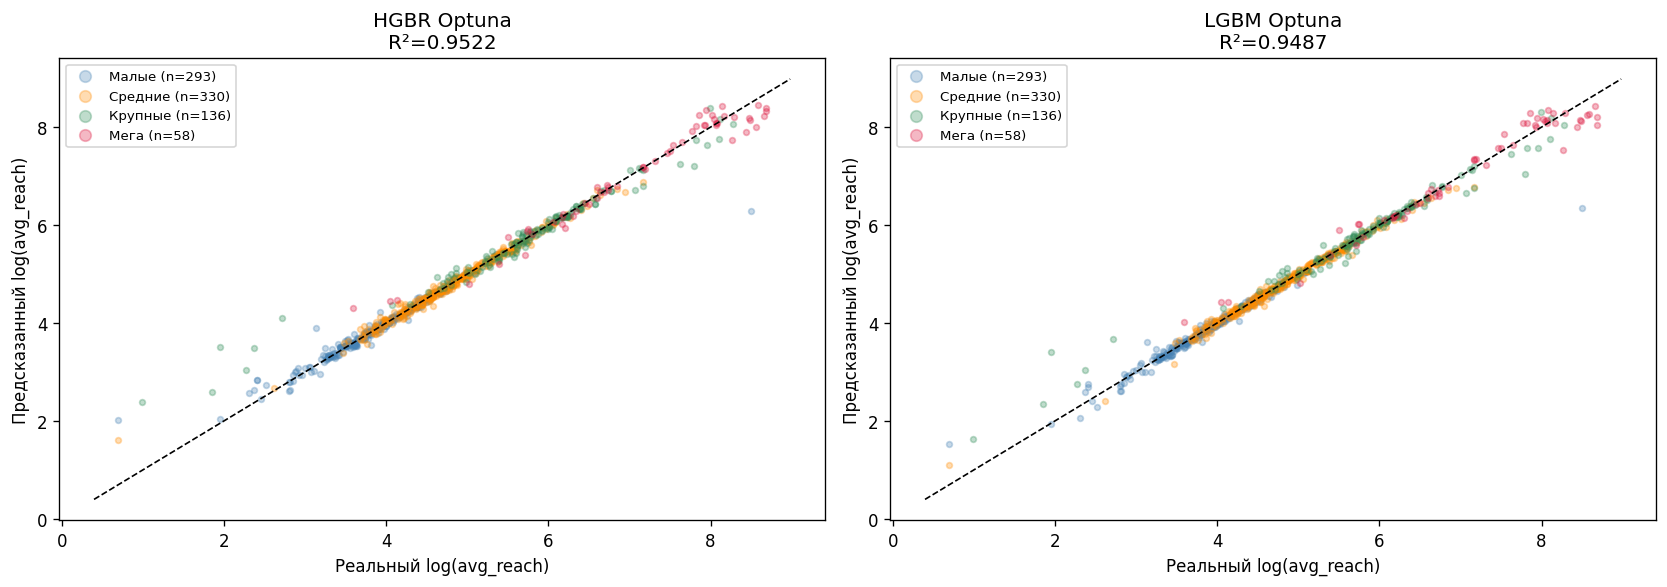

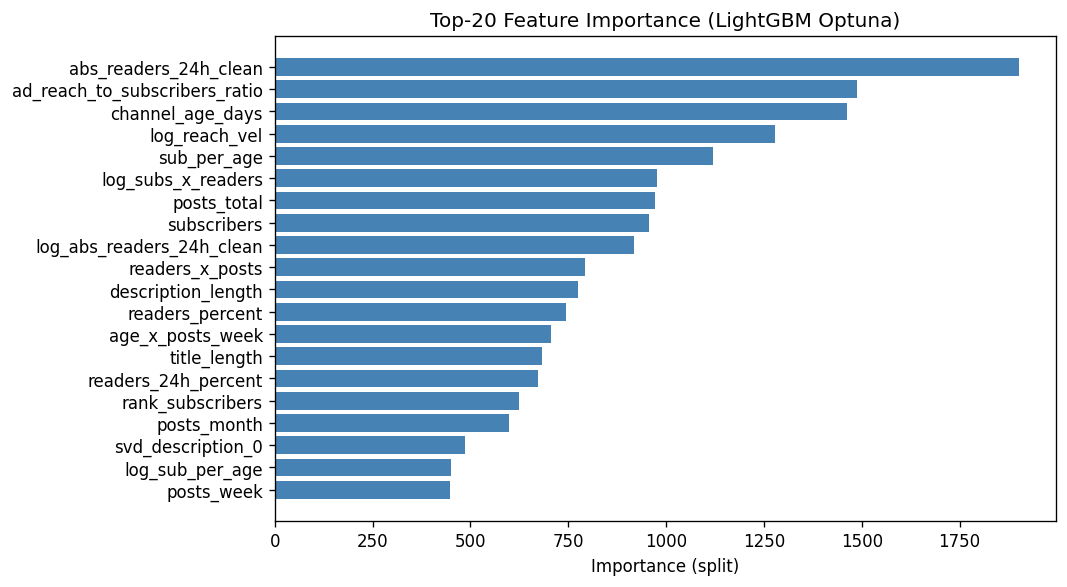

In [64]:
# Визуализация: scatter plot предсказанных vs реальных значений с цветовой дифференциацией по сегментам каналов
COLORS = ['steelblue', 'darkorange', 'seagreen', 'crimson']
BANDS  = [(0, 1000), (1000, 5000), (5000, 15000), (15000, 1e9)]
BNAMES = ['Малые', 'Средние', 'Крупные', 'Мега']

# Сравнение HGBR бейзлайна и оптимизированного LGBM по сегментам каналов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (yp, title) in zip(axes, [(p_hgbr_final, 'HGBR Optuna'), (p_lgb_final, 'LGBM Optuna')]):
    for (lo, hi), nm, col in zip(BANDS, BNAMES, COLORS):
        m = (subs_te > lo) & (subs_te <= hi)
        if m.sum() == 0: continue
        ax.scatter(y_te[m], yp[m], alpha=0.3, s=12, color=col, label=f'{nm} (n={m.sum()})')
    lo_ = min(y_te.min(), yp.min()) - 0.3
    hi_ = max(y_te.max(), yp.max()) + 0.3
    ax.plot([lo_, hi_], [lo_, hi_], 'k--', lw=1)
    ax.set_title(f'{title}\nR²={r2_score(y_te, yp):.4f}')
    ax.set_xlabel('Реальный log(avg_reach)')
    ax.set_ylabel('Предсказанный log(avg_reach)')
    ax.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.savefig('scatter.png', bbox_inches='tight'); plt.show()

# Важность признаков для оптимизированного LightGBM
fi = pd.DataFrame({'feature': X_tr.columns, 'importance': lgb_final.feature_importances_})
fi = fi.sort_values('importance', ascending=False).head(20)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi['feature'][::-1], fi['importance'][::-1], color='steelblue')
ax.set_title('Top-20 Feature Importance (LightGBM Optuna)')
ax.set_xlabel('Importance (split)')
plt.tight_layout()
plt.savefig('feature_importance_lgbm.png', bbox_inches='tight'); plt.show()

## 9. Сохранение лучшей модели

In [83]:
import joblib
import numpy as np
import pandas as pd

TARGET_COL = 'avg_reach'

try:
    tfidf_models
except NameError:
    tfidf_models = {}

try:
    CAT_COLS
except NameError:
    CAT_COLS = []

# Функция для подготовки входного датафрейма с нужными признаками и преобразованиями для модели HGBR
def prepare_input_for_hgbr_pipeline(df_src):
    df_work = df_src.copy()

    if df_work.columns.duplicated().any():
        df_work = df_work.loc[:, ~df_work.columns.duplicated()]

    # Добавляем отсутствующие числовые признаки
    for c in NUM_COLS:
        if c not in df_work.columns:
            df_work[c] = 0.0

    # TF-IDF + SVD
    for col, model_pair in (tfidf_models or {}).items():
        try:
            tfidf, svd = model_pair
            if col in df_work.columns:
                corpus = df_work[col].fillna('').astype(str).str.lower().str.strip()
                X_t = tfidf.transform(corpus)
                X_svd = svd.transform(X_t)
                for i in range(X_svd.shape[1]):
                    df_work[f'svd_{col}_{i}'] = X_svd[:, i]
        except Exception as e:
            print(f'WARN tfidf/svd failed for {col}: {e}')

    # Категориальные — приводим к строкам, без category dtype
    for c in CAT_COLS:
        if c not in df_work.columns:
            df_work[c] = 'unknown'
        x = df_work[c]
        if isinstance(x, pd.DataFrame):
            x = x.iloc[:, 0]
        df_work[c] = x.fillna('unknown').astype(str)

    # Числовые — в numeric
    for c in NUM_COLS:
        x = df_work[c]
        if isinstance(x, pd.DataFrame):
            x = x.iloc[:, 0]
        df_work[c] = pd.to_numeric(x, errors='coerce').fillna(0.0)

        if c in LOG_TRANSFORM:
            df_work[c] = np.log1p(np.clip(df_work[c], 0, None))

    return df_work

# Функция для вычисления статистик residuals (среднее и стандартное отклонение) для модели HGBR на заданном датафрейме
def compute_residual_stats_batch_hgbr(df_train, model, log_transform=True, target_col='avg_reach'):
    df_work = df_train.dropna(subset=[target_col]).copy()
    print(f'Строк после dropna: {len(df_work):,} (убрано {len(df_train)-len(df_work):,} NaN)')

    y_real = df_work[target_col].to_numpy(dtype=float)

    X_raw = prepare_input_for_hgbr_pipeline(df_work)

    y_pred_raw = model.predict(X_raw)
    y_pred = np.expm1(y_pred_raw) if log_transform else y_pred_raw
    residuals = y_real - y_pred

    print(f'Каналов обработано : {len(df_work):,}')
    print(f'RESIDUAL_MEAN      = {residuals.mean():,.1f}')
    print(f'RESIDUAL_STD       = {residuals.std():,.1f}')
    return residuals.mean(), residuals.std()

# Вычисляем статистики residuals для модели HGBR на полном датафрейме (может занять некоторое время)
RESIDUAL_MEAN, RESIDUAL_STD = compute_residual_stats_batch_hgbr(
    df,
    hgbr_final,
    log_transform=LOG_TRANSFORM,
    target_col=TARGET_COL
)

# Сохранение модели HGBR и метаданных для подготовки входных данных и нормализации residuals
joblib.dump(hgbr_final, 'hgbr.pkl')
joblib.dump({
    'NUM_COLS': NUM_COLS,
    'CAT_COLS': CAT_COLS,
    'LOG_TRANSFORM': LOG_TRANSFORM,
    'tfidf_models': tfidf_models,
    'RESIDUAL_MEAN': RESIDUAL_MEAN,
    'RESIDUAL_STD': RESIDUAL_STD,
    'TARGET_COL': TARGET_COL,
}, 'hgbr_meta.pkl')

print('Сохранено: hgbr.pkl + hgbr_meta.pkl')

Строк после dropna: 3,361 (убрано 885 NaN)
Каналов обработано : 3,361
RESIDUAL_MEAN      = 315.5
RESIDUAL_STD       = 950.0
Сохранено: hgbr.pkl + hgbr_meta.pkl


## 10. Загрузка модели

In [84]:
import joblib

# Загрузка модели HGBR и метаданных для подготовки входных данных и нормализации residuals
hgbr_final = joblib.load('hgbr.pkl')
meta = joblib.load('hgbr_meta.pkl')

NUM_COLS = meta['NUM_COLS']
CAT_COLS = meta.get('CAT_COLS', [])
LOG_TRANSFORM = meta['LOG_TRANSFORM']
tfidf_models = meta.get('tfidf_models', {})
RESIDUAL_MEAN = meta.get('RESIDUAL_MEAN', 0.0)
RESIDUAL_STD = meta.get('RESIDUAL_STD', 1.0)
TARGET_COL = meta.get('TARGET_COL', 'avg_reach')

print('HGBR модель загружена')
print(f'NUM_COLS       : {len(NUM_COLS)}')
print(f'CAT_COLS       : {len(CAT_COLS)}')
print(f'LOG_TRANSFORM  : {LOG_TRANSFORM}')
print(f'tfidf_models   : {list(tfidf_models.keys()) if tfidf_models else []}')
print(f'RESIDUAL_MEAN  : {RESIDUAL_MEAN:,.1f}')
print(f'RESIDUAL_STD   : {RESIDUAL_STD:,.1f}')
print(f'TARGET_COL     : {TARGET_COL}')

HGBR модель загружена
NUM_COLS       : 194
CAT_COLS       : 3
LOG_TRANSFORM  : ['subscribers', 'rank_subscribers', 'posts_total']
tfidf_models   : ['title', 'description', 'text_description']
RESIDUAL_MEAN  : 315.5
RESIDUAL_STD   : 950.0
TARGET_COL     : avg_reach


## 11. Оценка риска накрутки для всех каналов через HGBR

In [85]:
import numpy as np
import pandas as pd

# Проверяем, что все необходимые переменные определены, иначе задаём им значения по умолчанию
try:
    tfidf_models
except NameError:
    tfidf_models = {}

try:
    RESIDUAL_MEAN
except NameError:
    RESIDUAL_MEAN = 0.0

try:
    RESIDUAL_STD
except NameError:
    RESIDUAL_STD = 1.0

TARGET_COL = 'avg_reach'

# Если CAT_COLS нет — считаем, что категориальных нет
try:
    CAT_COLS
except NameError:
    CAT_COLS = []

# Функция для подготовки входного датафрейма с нужными признаками и преобразованиями для модели HGBR, с обработкой дублей колонок и безопасным преобразованием типов
def make_df_hgbr_safe(df_src, num_cols, cat_cols, log_transform):
    df_src = df_src.copy()

    if df_src.columns.duplicated().any():
        dup_cols = df_src.columns[df_src.columns.duplicated()].tolist()
        print(f'Найдены дубли колонок: {dup_cols[:10]}{" ..." if len(dup_cols) > 10 else ""}')
        df_src = df_src.loc[:, ~df_src.columns.duplicated()]

    num_cols = list(dict.fromkeys(num_cols))
    cat_cols = list(dict.fromkeys(cat_cols))

    # Числовые признаки
    for col in num_cols:
        if col not in df_src.columns:
            df_src[col] = 0.0

        x = df_src[col]
        if isinstance(x, pd.DataFrame):
            x = x.iloc[:, 0]

        vals = pd.to_numeric(x, errors='coerce').fillna(0.0)

        if col in log_transform:
            vals = np.log1p(np.clip(vals, 0, None))

        df_src[col] = vals

    # Категориальные признаки — строками, НЕ category dtype
    for col in cat_cols:
        if col not in df_src.columns:
            df_src[col] = 'unknown'

        x = df_src[col]
        if isinstance(x, pd.DataFrame):
            x = x.iloc[:, 0]

        df_src[col] = pd.Series(x).fillna('unknown').astype(str)

    return df_src

# Функция для предсказания avg_reach для одного канала через модель HGBR с безопасной обработкой входных данных и учетом TF-IDF + SVD признаков
def predict_channel_hgbr_safe(channel_dict):
    df_new = pd.DataFrame([channel_dict]).copy()

    if df_new.columns.duplicated().any():
        df_new = df_new.loc[:, ~df_new.columns.duplicated()]

    # TF-IDF + SVD
    for col, model_pair in (tfidf_models or {}).items():
        try:
            tfidf, svd = model_pair
            if col in df_new.columns:
                corpus = df_new[col].fillna('').astype(str).str.lower().str.strip()
                X_t = tfidf.transform(corpus)
                X_svd = svd.transform(X_t)
                for i in range(X_svd.shape[1]):
                    df_new[f'svd_{col}_{i}'] = X_svd[:, i]
        except Exception:
            pass

    # Подготовка под модель
    X_new = make_df_hgbr_safe(df_new, NUM_COLS, CAT_COLS, LOG_TRANSFORM)

    # Если это sklearn Pipeline / ColumnTransformer, подаём raw DataFrame
    # Если это обычный HGBR, можно сузить до нужных фичей
    if hasattr(hgbr_final, 'feature_names_in_'):
        train_cols = list(hgbr_final.feature_names_in_)
        for c in train_cols:
            if c not in X_new.columns:
                X_new[c] = 'unknown' if c in CAT_COLS else 0.0
        X_new = X_new[train_cols]

    pred = hgbr_final.predict(X_new)[0]
    return float(np.expm1(pred) if LOG_TRANSFORM else pred)

# Функция для батч-скоринга каналов через модель HGBR с безопасной обработкой данных, расчетом residuals и z-оценки, а также формированием вердикта по риску накрутки
def bot_score_batch_hgbr(df_input, debug=True, max_errors=20):
    results = []
    errors = []

    for i, (_, row) in enumerate(df_input.iterrows()):
        channel_dict = row.to_dict()
        real_reach = row.get(TARGET_COL, np.nan)

        if pd.isna(real_reach):
            continue

        try:
            pred = predict_channel_hgbr_safe(channel_dict)
            residual = real_reach - pred
            z = (residual - RESIDUAL_MEAN) / RESIDUAL_STD if RESIDUAL_STD and RESIDUAL_STD > 0 else 0.0

            readers_pct = channel_dict.get('readers_percent', 0)
            reach_ratio = channel_dict.get('ad_reach_to_subscribers_ratio', 0)
            subscribers = channel_dict.get('subscribers', 0)

            readers_pct = float(readers_pct) if pd.notna(readers_pct) else 0.0
            reach_ratio = float(reach_ratio) if pd.notna(reach_ratio) else 0.0
            subscribers = float(subscribers) if pd.notna(subscribers) else 0.0

            risk_score = 0

            # Z-score
            if z < -2.5:
                risk_score += 3
            elif z < -1.0:
                risk_score += 2

            # readers_percent
            if readers_pct < 20:
                risk_score += 2
            elif readers_pct < 40:
                risk_score += 1

            # reach/subs
            if reach_ratio < 0.05:
                risk_score += 2
            elif reach_ratio < 0.10:
                risk_score += 1

            verdict = (
                'ЖИВОЙ' if risk_score == 0 else
                'СРЕДНИЙ' if risk_score <= 2 else
                'БОТЫ'
            )

            results.append({
                'username': row.get('channel_username', ''),
                'title': row.get('title', ''),
                'subscribers': subscribers,
                'avg_reach': float(real_reach),
                'pred_reach': float(pred),
                'residual': float(residual),
                'z_score': float(z),
                'readers_pct': readers_pct,
                'reach_ratio': reach_ratio,
                'risk_score': int(risk_score),
                'verdict': verdict,
            })

        except Exception as e:
            if len(errors) < max_errors:
                errors.append({
                    'row_idx': i,
                    'title': str(row.get('title', ''))[:80],
                    'error': repr(e)
                })
            continue

    df_res = pd.DataFrame(results)

    print('=' * 70)
    print('РЕЗУЛЬТАТ БАТЧ-СКОРИНГА ЧЕРЕЗ HGBR')
    print('=' * 70)
    print(f'Успешно обработано: {len(df_res):,}')
    print(f'Ошибок           : {len(errors):,}')

    if errors and debug:
        print('\nПервые ошибки:')
        for er in errors:
            print(f"  row={er['row_idx']:>4} | {er['title'][:40]:<40} | {er['error']}")

    return df_res, errors

# Генерация предсказаний и оценка риска накрутки для всех каналов через модель HGBR, с выводом статистики по результату
print('Генерация предсказаний и оценка риска накрутки для всех каналов через HGBR')
df_scored, errors = bot_score_batch_hgbr(df, debug=True, max_errors=20)

# Выводим статистику по результату
if df_scored.empty:
    print('\ndf_scored пустой. Сначала исправь ошибки выше.')
else:
    print(f'\nОбработано: {len(df_scored):,} каналов\n')

    print('=== ОБЩАЯ СТАТИСТИКА ===')
    vc = df_scored['verdict'].value_counts()
    for v, n in vc.items():
        pct = n / len(df_scored) * 100
        print(f'  {v:<10} {n:>5,} каналов ({pct:.1f}%)')

    print('\n=== ТОП-20 ЖИВЫХ КАНАЛОВ (по avg_reach) ===')
    top_live = (
        df_scored[df_scored['verdict'] == 'ЖИВОЙ']
        .sort_values('avg_reach', ascending=False)
        .head(20)
    )

    if top_live.empty:
        print('Нет каналов с вердиктом ЖИВОЙ')
    else:
        print(top_live[
            ['username', 'title', 'subscribers', 'avg_reach',
             'readers_pct', 'reach_ratio', 'risk_score']
        ].to_string(index=False))

    print('\n=== ТОП-20 НАКРУЧЕННЫХ (по risk_score + подписчики) ===')
    top_bots = (
        df_scored[df_scored['verdict'] == 'БОТЫ']
        .sort_values(['risk_score', 'subscribers'], ascending=False)
        .head(20)
    )

    if top_bots.empty:
        print('Нет каналов с вердиктом БОТЫ')
    else:
        print(top_bots[
            ['username', 'title', 'subscribers', 'avg_reach',
             'readers_pct', 'reach_ratio', 'risk_score']
        ].to_string(index=False))

    print('\n=== СРЕДНИЕ МЕТРИКИ ПО ГРУППАМ ===')
    print(df_scored.groupby('verdict')[
        ['subscribers', 'avg_reach', 'pred_reach', 'residual',
         'readers_pct', 'reach_ratio', 'z_score', 'risk_score']
    ].mean().round(2).to_string())

Генерация предсказаний и оценка риска накрутки для всех каналов через HGBR
РЕЗУЛЬТАТ БАТЧ-СКОРИНГА ЧЕРЕЗ HGBR
Успешно обработано: 3,361
Ошибок           : 0

Обработано: 3,361 каналов

=== ОБЩАЯ СТАТИСТИКА ===
  СРЕДНИЙ    2,694 каналов (80.2%)
  ЖИВОЙ        520 каналов (15.5%)
  БОТЫ         147 каналов (4.4%)

=== ТОП-20 ЖИВЫХ КАНАЛОВ (по avg_reach) ===
username                                     title  subscribers   avg_reach  readers_pct  reach_ratio  risk_score
                    Испанский язык / learn spanish       4947.0 5400.000000         95.0     7.303618           0
         Siberian Teacher / Сибирский Учитель 👩🏻‍🏫      18461.0 5133.333333         42.0     1.903039           0
                                   Просто Японский      12216.0 4966.666667         55.0     2.665521           0
                            Английский язык с нуля       3425.0 4866.666667        127.0     9.404672           0
                                      Русский язык      21559.0 4800.00

In [86]:
# Анализ слов в названии канала относительно HGBR:
# 1) корреляция с реальным avg_reach
# 2) корреляция с pred_reach_hgbr
# 3) корреляция с residual_hgbr = avg_reach - pred_reach_hgbr

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import pearsonr

# Копируем df для анализа слов в названии, чтобы не мешать основному df
df_words = df_clean.copy()

required_cols = ['title', 'avg_reach']
for c in required_cols:
    if c not in df_words.columns:
        raise ValueError(f'Нет колонки: {c}')

# Если предсказаний HGBR ещё нет — посчитаем
if 'pred_reach_hgbr' not in df_words.columns:
    preds = []

    for _, row in df_words.iterrows():
        try:
            pred = predict_channel_hgbr_safe(row.to_dict())
        except Exception:
            pred = np.nan
        preds.append(pred)

    df_words['pred_reach_hgbr'] = preds

# Residual
df_words['residual_hgbr'] = df_words['avg_reach'] - df_words['pred_reach_hgbr']

# Убираем строки без нужных значений
df_words = df_words.dropna(subset=['title', 'avg_reach', 'pred_reach_hgbr', 'residual_hgbr']).copy()

# Подготавливаем текст для TF-IDF
corpus = df_words['title'].fillna('').astype(str).str.lower().str.strip()

y_reach = df_words['avg_reach'].to_numpy(dtype=float)
y_pred = df_words['pred_reach_hgbr'].to_numpy(dtype=float)
y_resid = df_words['residual_hgbr'].to_numpy(dtype=float)

# Настройки TF-IDF: только униграммы, не менее 5 каналов со словом, максимум 5000 слов
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    min_df=5,
    sublinear_tf=True
)

X_t = tfidf.fit_transform(corpus)
vocab = np.array(tfidf.get_feature_names_out())

# Функция для вычисления корреляции Пирсона между наличием слова в названии и целевыми переменными (реальный reach, предсказанный reach, residual), с фильтрацией по минимальной сумме слова
def compute_word_corrs(X_sparse, y, min_word_sum=10):
    corrs = []

    for i in range(X_sparse.shape[1]):
        col = X_sparse.getcol(i).toarray().ravel()

        if col.sum() < min_word_sum:
            corrs.append(0.0)
            continue

        if np.std(col) == 0 or np.std(y) == 0:
            corrs.append(0.0)
            continue

        r, _ = pearsonr(col, y)
        corrs.append(r if not np.isnan(r) else 0.0)

    return np.array(corrs)

corr_reach = compute_word_corrs(X_t, y_reach)
corr_pred  = compute_word_corrs(X_t, y_pred)
corr_resid = compute_word_corrs(X_t, y_resid)

# Функция для печати топ-N слов с наибольшей положительной или отрицательной корреляцией, с выводом средней реального reach и количества каналов для каждого слова
def print_top_words(title, corrs, X_sparse, y, vocab, top_n=20, reverse=False):
    print(f'\n=== {title} ===')

    order = corrs.argsort()[::-1] if reverse else corrs.argsort()

    shown = 0
    for idx in order:
        mask = X_sparse.getcol(idx).toarray().ravel() > 0
        n = int(mask.sum())

        if n < 5:
            continue

        avg_val = float(np.mean(y[mask])) if n > 0 else np.nan

        print(
            f'  "{vocab[idx]:<25}"  '
            f'corr={corrs[idx]:+.3f}  '
            f'mean={avg_val:,.0f}  '
            f'n={n}'
        )

        shown += 1
        if shown >= top_n:
            break

print_top_words(
    'ХУДШИЕ слова в названии по REAL avg_reach',
    corr_reach, X_t, y_reach, vocab,
    top_n=20, reverse=False
)

print_top_words(
    'ЛУЧШИЕ слова в названии по REAL avg_reach',
    corr_reach, X_t, y_reach, vocab,
    top_n=20, reverse=True
)

print_top_words(
    'ХУДШИЕ слова в названии по PRED avg_reach (HGBR)',
    corr_pred, X_t, y_pred, vocab,
    top_n=20, reverse=False
)

print_top_words(
    'ЛУЧШИЕ слова в названии по PRED avg_reach (HGBR)',
    corr_pred, X_t, y_pred, vocab,
    top_n=20, reverse=True
)

# 3. Слова и residual HGBR
# residual < 0 : канал хуже ожидания модели
# residual > 0 : канал лучше ожидания модели
print_top_words(
    'ХУДШИЕ слова в названии по RESIDUAL (хуже ожидания HGBR)',
    corr_resid, X_t, y_resid, vocab,
    top_n=20, reverse=False
)

print_top_words(
    'ЛУЧШИЕ слова в названии по RESIDUAL (лучше ожидания HGBR)',
    corr_resid, X_t, y_resid, vocab,
    top_n=20, reverse=True
)


=== ХУДШИЕ слова в названии по REAL avg_reach ===
  "детей                    "  corr=-0.030  mean=107  n=40
  "pro                      "  corr=-0.027  mean=65  n=21
  "онлайн                   "  corr=-0.026  mean=172  n=77
  "language                 "  corr=-0.023  mean=116  n=26
  "без                      "  corr=-0.022  mean=122  n=24
  "español                  "  corr=-0.021  mean=105  n=19
  "репетитор                "  corr=-0.021  mean=82  n=18
  "разговорный              "  corr=-0.021  mean=106  n=22
  "de                       "  corr=-0.021  mean=126  n=20
  "методика                 "  corr=-0.020  mean=112  n=19
  "by                       "  corr=-0.020  mean=110  n=18
  "китайского               "  corr=-0.019  mean=109  n=17
  "языков                   "  corr=-0.019  mean=107  n=18
  "for                      "  corr=-0.019  mean=151  n=28
  "языка                    "  corr=-0.019  mean=206  n=88
  "языки                    "  corr=-0.018  mean=157  n=28
  "от  

## Краткие выводы

### Что ухудшает reach
- Слова: онлайн, школа, репетитор, language, english, английского языка
- Формальные и “каталожные” формулировки
- Перегруженные длинные конструкции
- Формы типа: языков, языка

Итог: выглядит как типовая услуга, значит хуже привлекает внимание

---

### Что улучшает reach
- Простые, разговорные формулировки
- Конкретика: язык, немецкий, русский
- Конструкции с результатом:
  - с нуля
  - учим

Итог: быстрее считывается и понятнее

---

### Главный паттерн
- Просто и понятно лучше, чем формально и сложно
- Один язык + одно обещание лучше, чем длинное описание

---

### Пример
- Плохо: Онлайн школа английского языка
- Лучше: Английский с нуля
- Лучше: Учим английский

---

### Важно
- Влияние слов слабое (corr ~0.03–0.06)
- Название — вторичный фактор, контент важнее

---

### Итог
Названия должны быть короткими, простыми и с явной пользой, необходимо избегать “школьно-каталожного” стиля